# 🧬 BÁO CÁO TỔNG HỢP: PHÂN LOẠI CẤU TRÚC PROTEIN ỨNG DỤNG TDA

Notebook này trình bày toàn bộ luồng thực thi (pipeline) của dự án. Bao gồm các bước: Tiền xử lý dữ liệu, Minh họa trực quan các khái niệm TDA (Vietoris-Rips, Persistence Diagram, Persistence Image) cho 3 cấu trúc đại diện, và cuối cùng là huấn luyện mô hình học máy (SVM) để so sánh hiệu suất.

## 1. Import Thư viện và Cấu hình

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
from gudhi.representations import PersistenceImage
from sklearn.preprocessing import LabelEncoder

# Import modules từ project
from src import config
from src.preprocessing import download_pdb_data, preprocess_protein_data
from src.tda import process_tda
from src.features import compute_geometric_features, compute_pimage_features
from src.models import SVMClassifier

# IMPORT ĐÚNG CÁC HÀM CỦA BẠN
from src.utils import (
    plot_multidim_filtration, 
    plot_h1_persistence_diagram, 
    plot_persistence_image,
    plot_confusion_matrix, 
    plot_model_comparison, 
    plot_feature_space, 
    plot_pca_decision_boundary
)

print("Môi trường đã sẵn sàng!")

Môi trường đã sẵn sàng!


## 2. Tải và Tiền xử lý Dữ liệu

In [ ]:
print("[*] Đang thực hiện Tải và Tiền xử lý dữ liệu...")
fetched_groups = download_pdb_data(limit_per_class=20, raw_dir=config.RAW_DATA_DIR)
dataset = preprocess_protein_data(fetched_groups, config.RAW_DATA_DIR, config.PROCESSED_DATA_DIR)
print(f"\nHoàn tất xử lý {len(dataset)} proteins.")

[*] Đang thực hiện Tải và Tiền xử lý dữ liệu...

2. BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU
[DONE] 1LT1   | Nhãn: alpha_helix  | Số điểm CA: 384
[DONE] 3MGN   | Nhãn: alpha_helix  | Số điểm CA: 272
[DONE] 3HE4   | Nhãn: alpha_helix  | Số điểm CA: 356
[DONE] 3MIW   | Nhãn: alpha_helix  | Số điểm CA: 432
[DONE] 3HE5   | Nhãn: alpha_helix  | Số điểm CA: 282
[DONE] 2YF2   | Nhãn: alpha_helix  | Số điểm CA: 364
[DONE] 1OVV   | Nhãn: alpha_helix  | Số điểm CA: 288
[DONE] 1JM0   | Nhãn: alpha_helix  | Số điểm CA: 288
[DONE] 3LT6   | Nhãn: alpha_helix  | Số điểm CA: 350
[DONE] 3H7X   | Nhãn: alpha_helix  | Số điểm CA: 319
[DONE] 3LT7   | Nhãn: alpha_helix  | Số điểm CA: 348
[DONE] 2XDJ   | Nhãn: alpha_helix  | Số điểm CA: 396
[DONE] 2ZFC   | Nhãn: alpha_helix  | Số điểm CA: 132
[DONE] 1OVR   | Nhãn: alpha_helix  | Số điểm CA: 192
[DONE] 1FE6   | Nhãn: alpha_helix  | Số điểm CA: 205
[DONE] 3IF4   | Nhãn: alpha_helix  | Số điểm CA: 391
[DONE] 1EC5   | Nhãn: alpha_helix  | Số điểm CA: 144
[DONE] 2GUV   | Nhãn

## 3. Trực quan hóa TDA cho các Cấu trúc Đại diện


 PHÂN TÍCH ĐẠI DIỆN: 1LT1

--- Đang vẽ Filtration đa chiều cho Protein 1LT1 ---
  [+] Epsilon 0.50: 1717 cạnh, 2626 mặt tam giác.
  [+] Epsilon 0.90: 7196 cạnh, 55701 mặt tam giác.
  [+] Epsilon 1.20: 13422 cạnh, 220860 mặt tam giác.
  [+] Epsilon 1.50: 19593 cạnh, 490659 mặt tam giác.


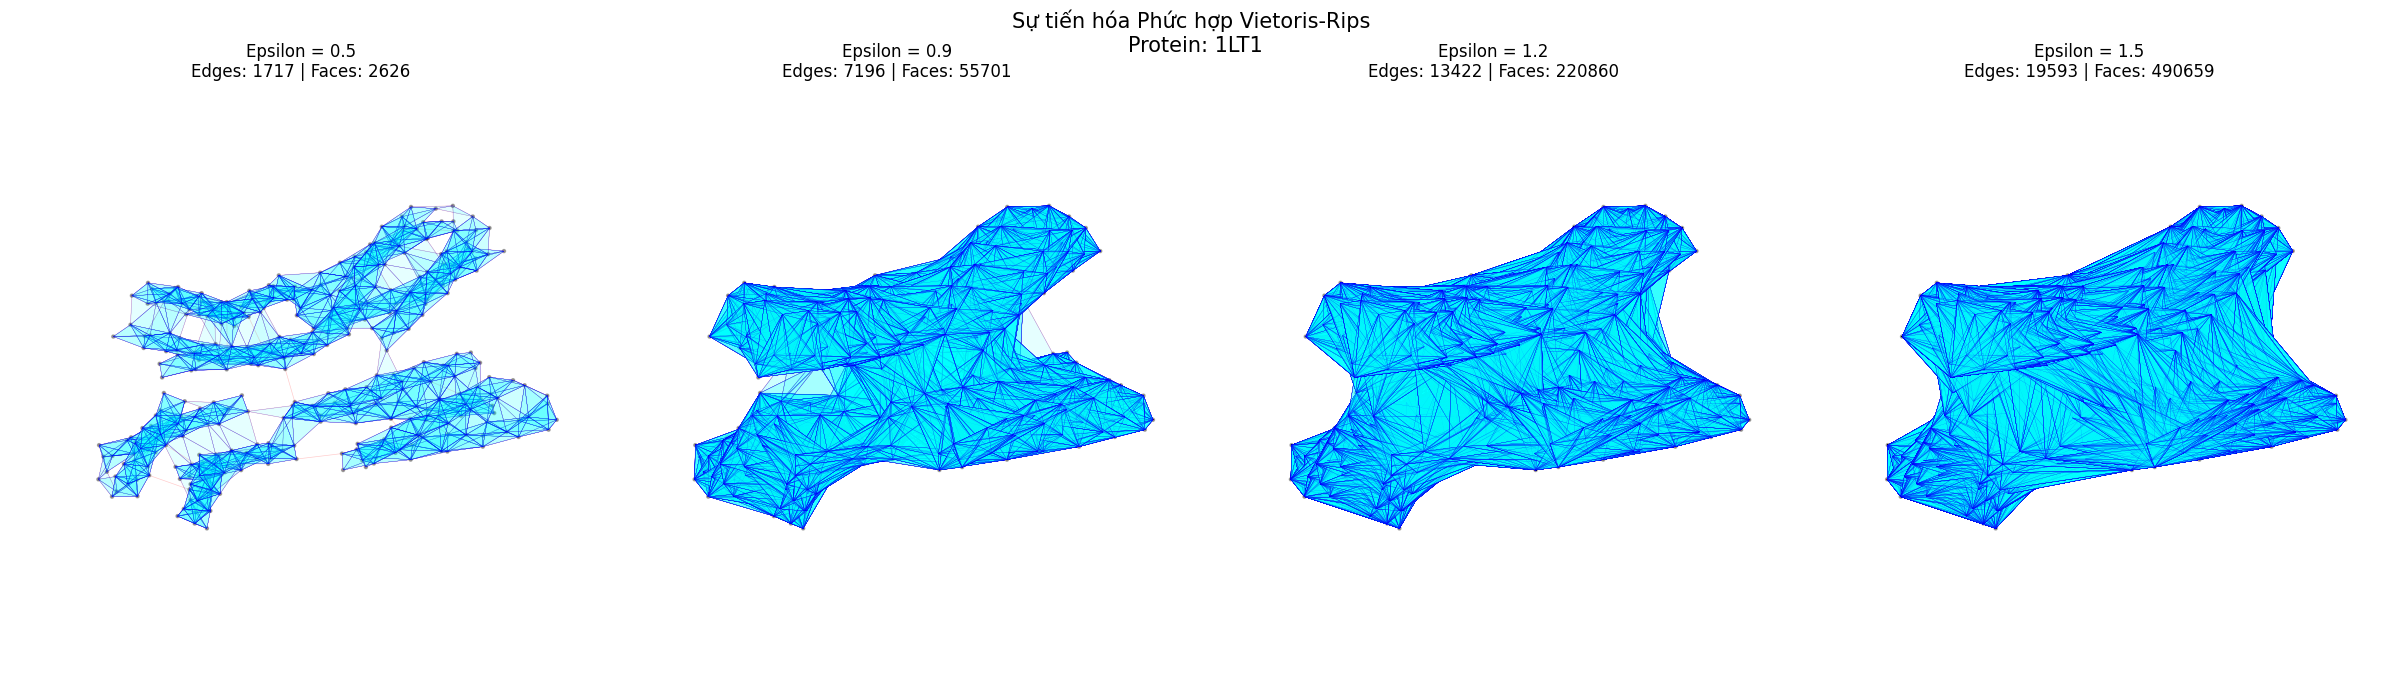

/home/huynh-gia-bao/Documents/protein-structure-classification-tda/env/lib/python3.12/site-packages/gudhi/persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Figure size 700x700 with 0 Axes>

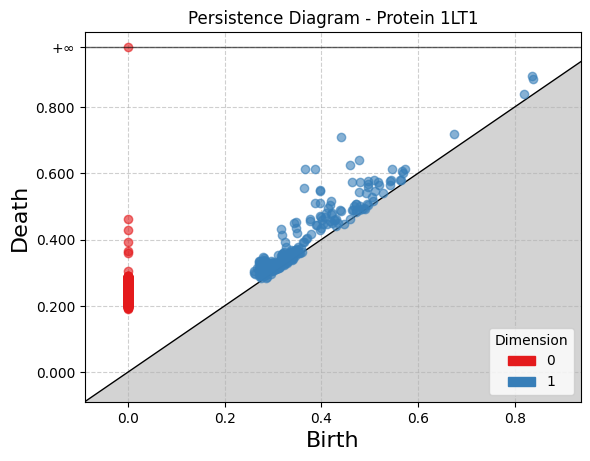

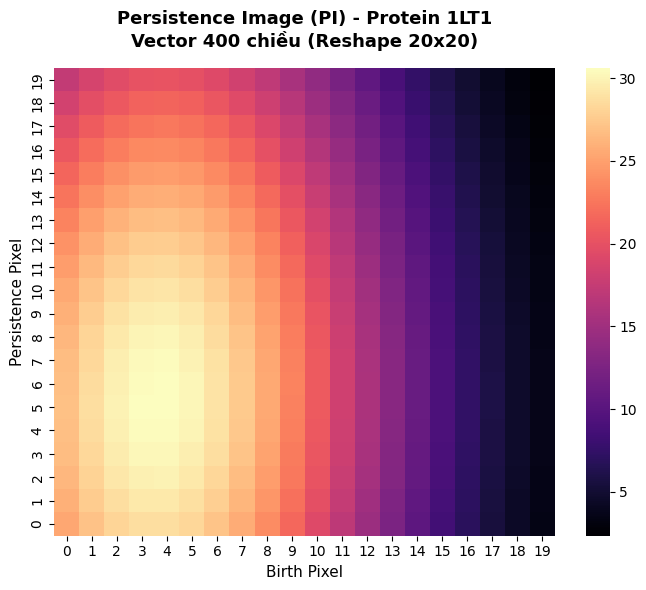


 PHÂN TÍCH ĐẠI DIỆN: 7P93

--- Đang vẽ Filtration đa chiều cho Protein 7P93 ---
  [+] Epsilon 0.50: 674 cạnh, 356 mặt tam giác.
  [+] Epsilon 0.90: 2933 cạnh, 10507 mặt tam giác.
  [+] Epsilon 1.20: 6203 cạnh, 52325 mặt tam giác.
  [+] Epsilon 1.50: 10612 cạnh, 168300 mặt tam giác.


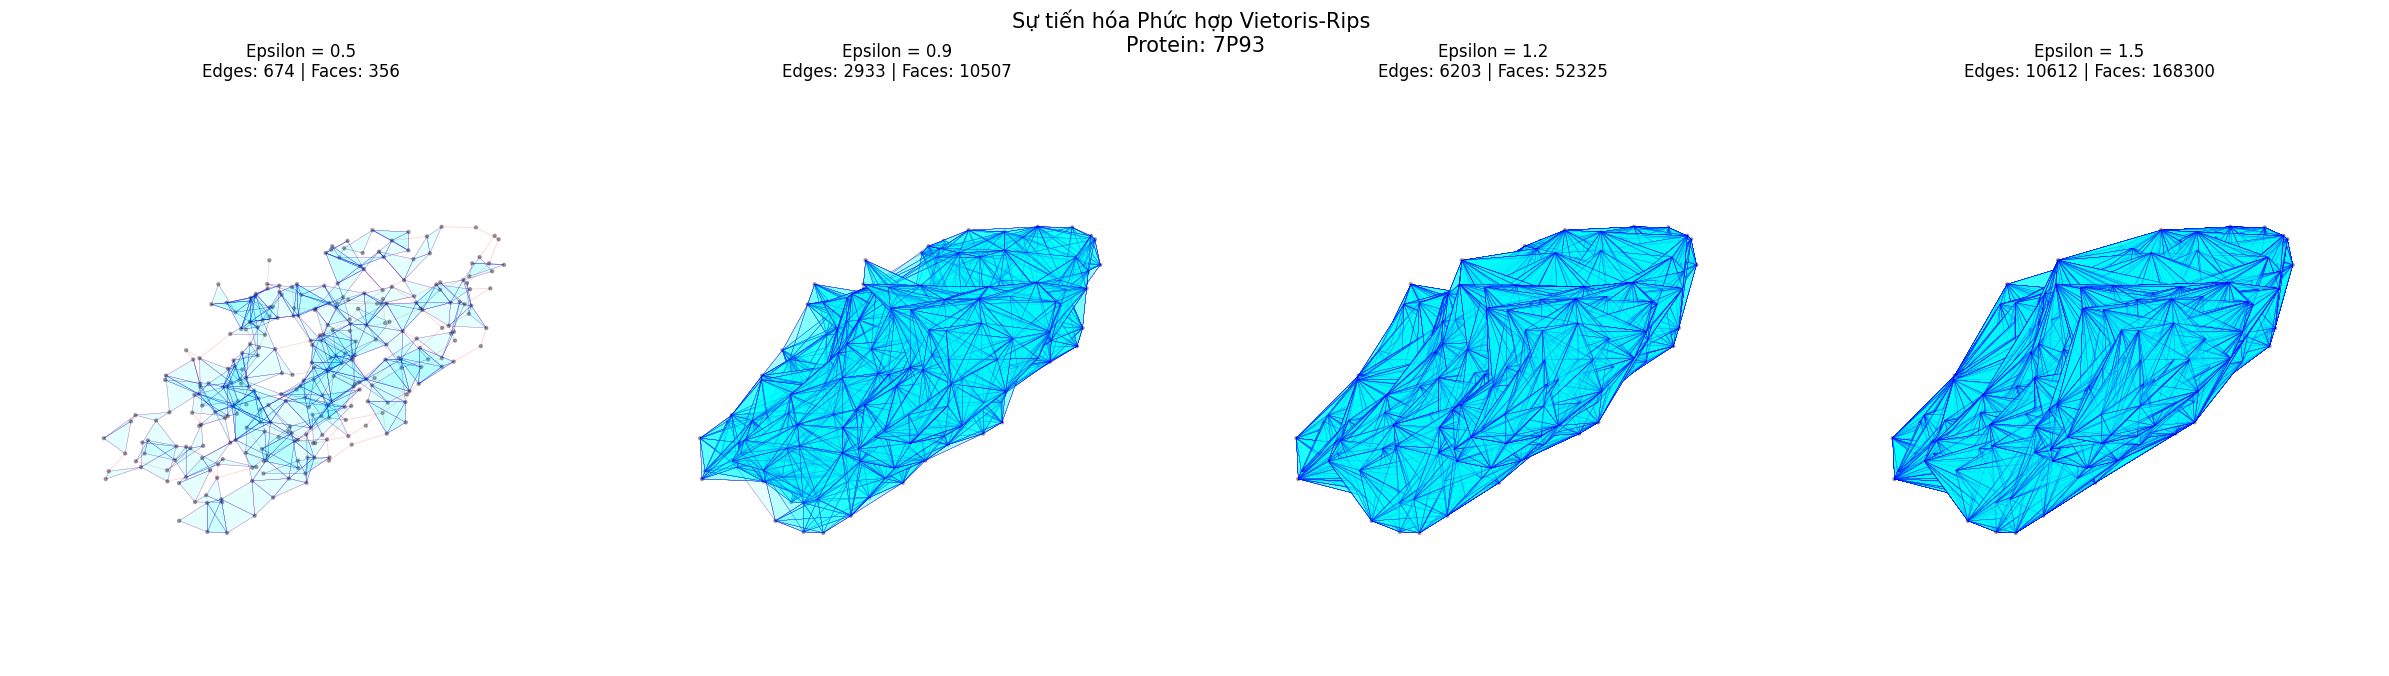

<Figure size 700x700 with 0 Axes>

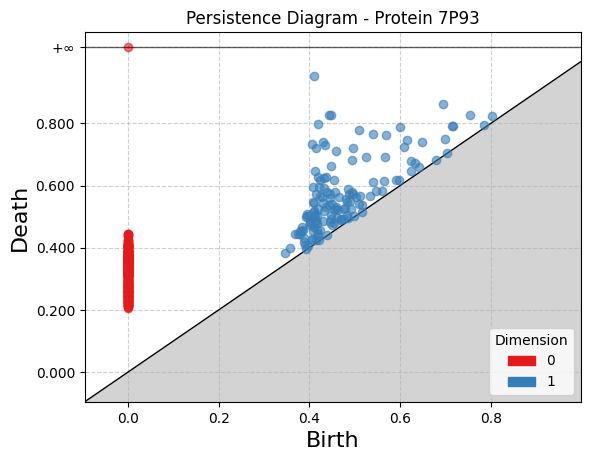

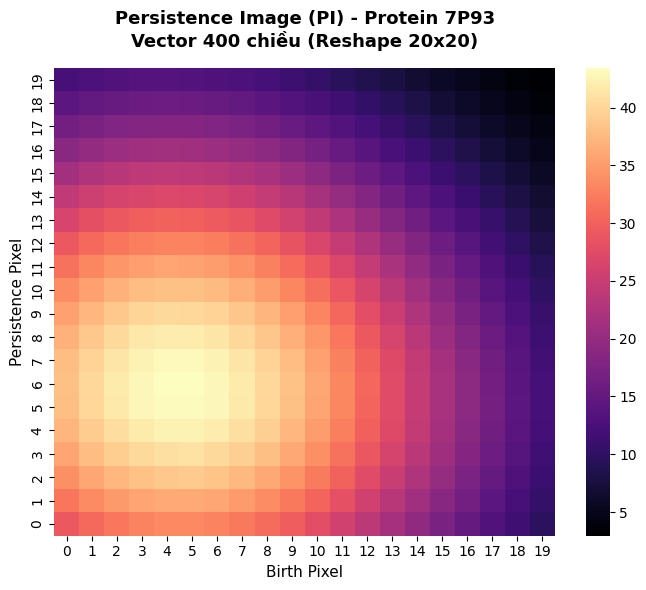


 PHÂN TÍCH ĐẠI DIỆN: 6E2A

--- Đang vẽ Filtration đa chiều cho Protein 6E2A ---
  [+] Epsilon 0.50: 590 cạnh, 180 mặt tam giác.
  [+] Epsilon 0.90: 2845 cạnh, 8471 mặt tam giác.
  [+] Epsilon 1.20: 6232 cạnh, 45735 mặt tam giác.
  [+] Epsilon 1.50: 10866 cạnh, 152808 mặt tam giác.


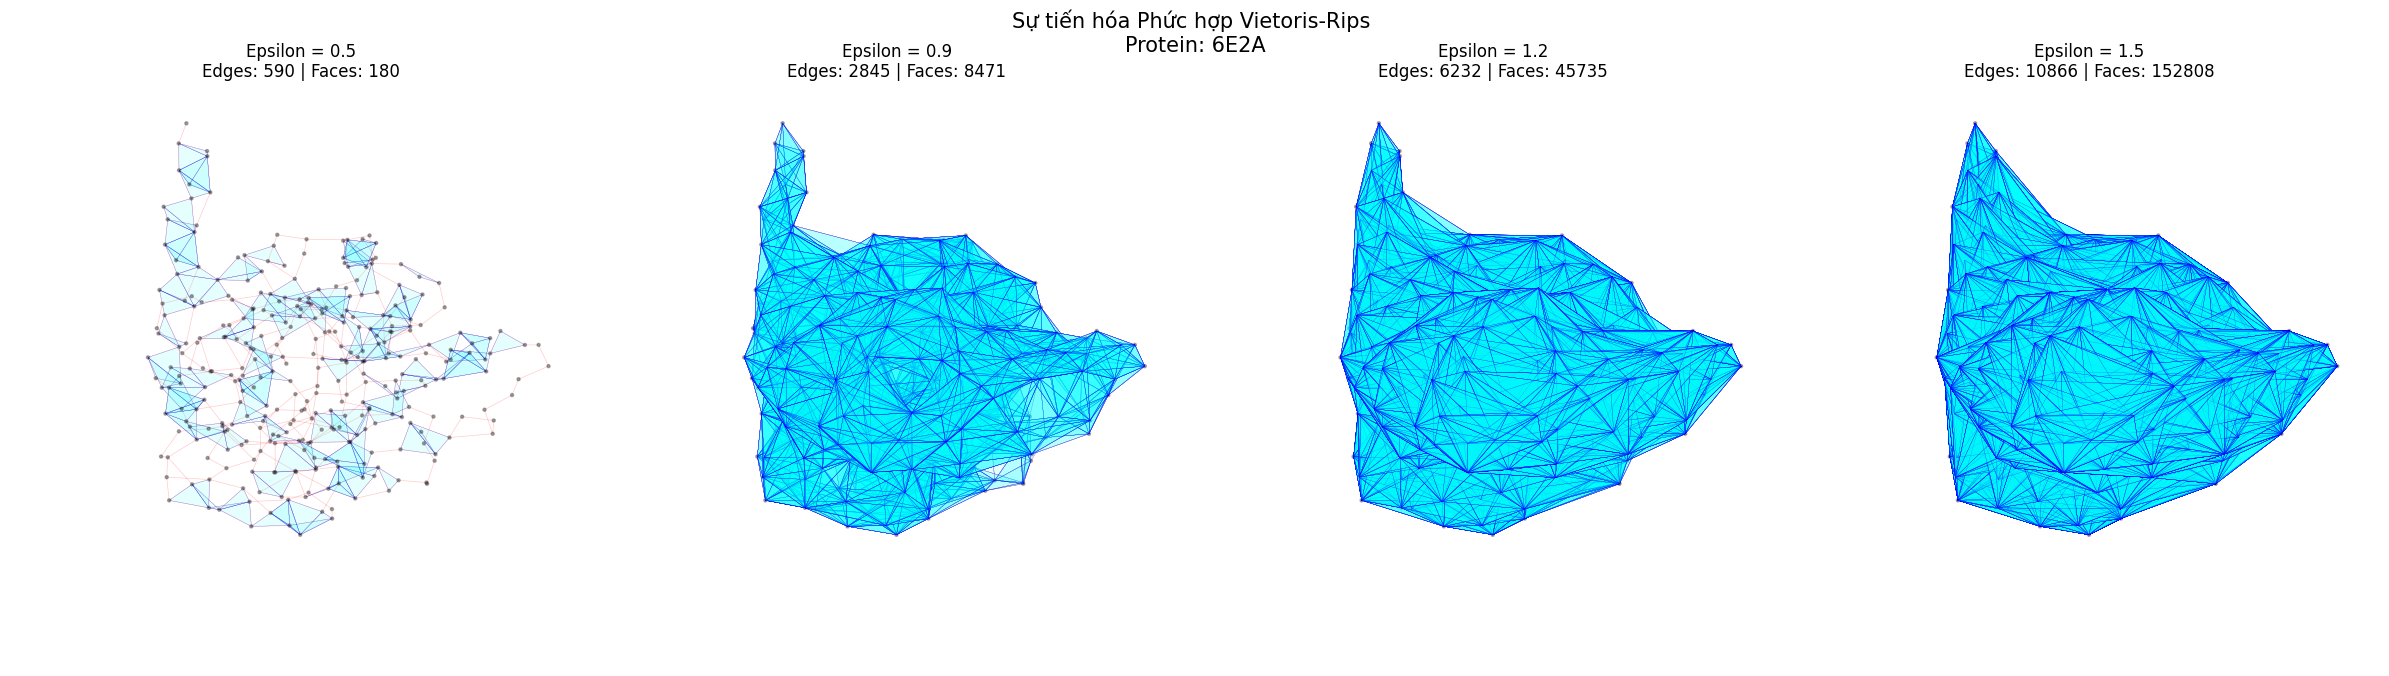

<Figure size 700x700 with 0 Axes>

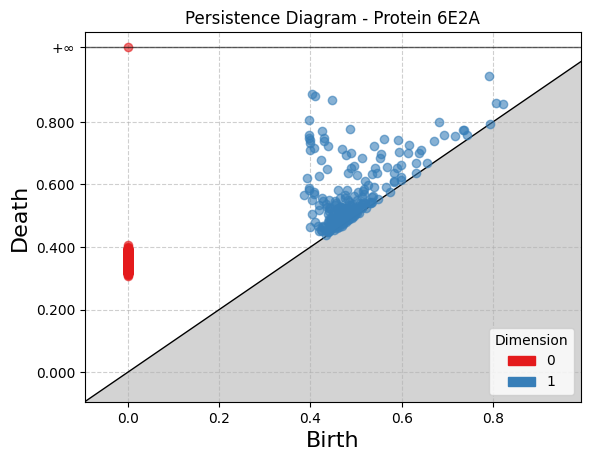

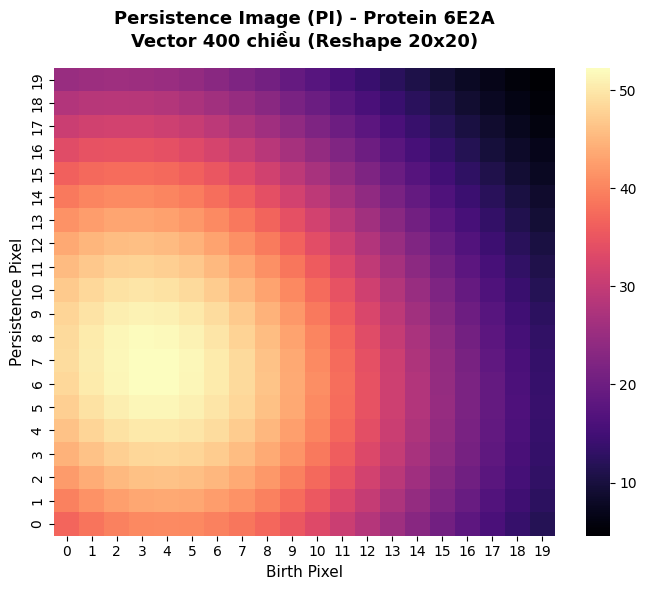

In [3]:
representative_pids = ['1lt1', '7p93', '6e2a']

eps_list = [0.5, 0.9, 1.2, 1.5]

pi_transformer = PersistenceImage(
    bandwidth=config.PI_PARAMS["bandwidth"],
    weight=config.PI_PARAMS["weight"],
    resolution=config.PI_PARAMS["resolution"]
)

for record in dataset:
    pid = record["pdb_id"].lower()
    if pid in representative_pids:
        print(f"\n{'='*70}\n PHÂN TÍCH ĐẠI DIỆN: {pid.upper()}\n{'='*70}")
        
        record = next(item for item in dataset if item["pdb_id"].lower() == pid)
        points = record["point_cloud"]
        
        # 3.1 VẼ RIPS FILTRATION 3D 
        plot_multidim_filtration(points, eps_list, pid)
        plt.show()
        
        rips_complex = gd.RipsComplex(points=points, max_edge_length=2.5)
        st = rips_complex.create_simplex_tree(max_dimension=2)
        persistence = st.persistence()
        
        # 3.2 VẼ PERSISTENCE DIAGRAM 
        plot_h1_persistence_diagram(persistence, pid)
        plt.show()
        
        h1_intervals = np.array([interval[1] for interval in persistence if interval[0] == 1])
        if len(h1_intervals) == 0:
            h1_intervals = np.array([[0.0, 0.0]])
            
        pi_vector = pi_transformer.fit_transform([h1_intervals])[0]
        
        # 3.3 VẼ PERSISTENCE IMAGE
        plot_persistence_image(pi_vector, pid)
        plt.show()

## 4. Xử lý Đặc trưng hàng loạt (Feature Extraction)

In [4]:
print("[*] Bước 1: Tính toán TDA...")
process_tda()
print("\n[*] Bước 2: Hình học Truyền thống...")
compute_geometric_features(config.PROCESSED_DATA_FILE, config.GEO_FEATURES_DIR)
print("\n[*] Bước 3: Vector hóa PD thành Persistence Image...")
compute_pimage_features(config.PROCESSED_DATA_FILE, config.TDA_FEATURES_FILE, config.PIMAGE_FEATURES_DIR)

[*] Bước 1: Tính toán TDA...
 BẮT ĐẦU PHÂN TÍCH TDA (RIPS FILTRATION & H1)

 BẢNG PHÂN TÍCH THỜI GIAN TỒN TẠI VÒNG H1 THEO TỪNG NHÓM
      Label  Tong_So_Vong_H1  TB_So_Vong_Moi_Protein  Do_Ben_H1_Trung_Binh  Do_Ben_H1_Lon_Nhat
alpha_helix             3313                  165.65                 0.058               1.165
 beta_sheet             3076                  153.80                 0.086               0.570
      mixed             4369                  218.45                 0.080               0.596

[*] Bước 2: Hình học Truyền thống...

[*] Đang tính toán Đặc trưng hình học (Geometric Features)...
  -> [OK] Đã lưu thành công tại: /home/huynh-gia-bao/Documents/protein-structure-classification-tda/features/geometric_features
PDB_ID       Label  Num Points  Bounding Radius  Mean Curvature  Mean Neighbor Dist
  1LT1 alpha_helix         384           2.9810          0.1037              0.2293
  3MGN alpha_helix         272           3.3930          0.1084              0.2993
  3HE4

## 5. Huấn luyện SVM và Đánh giá

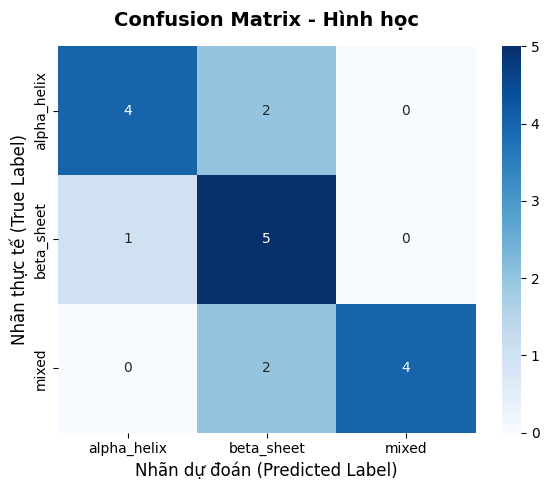

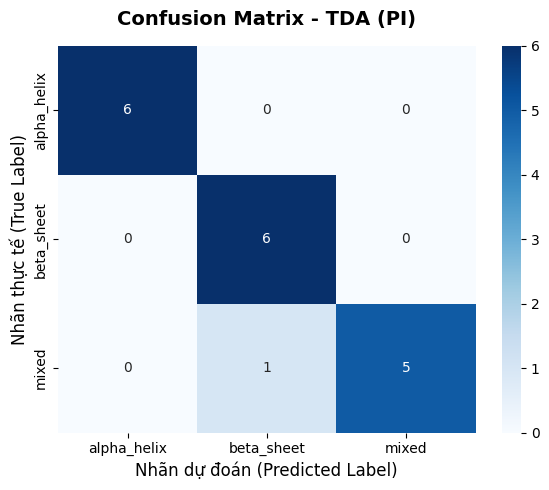

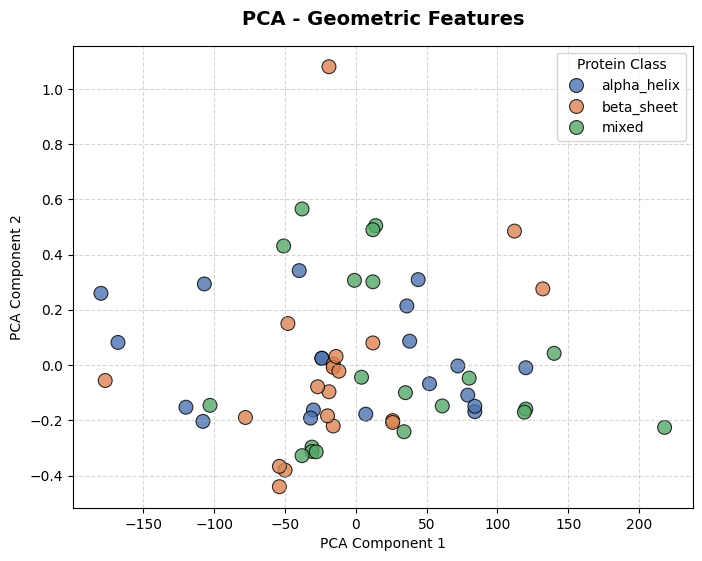

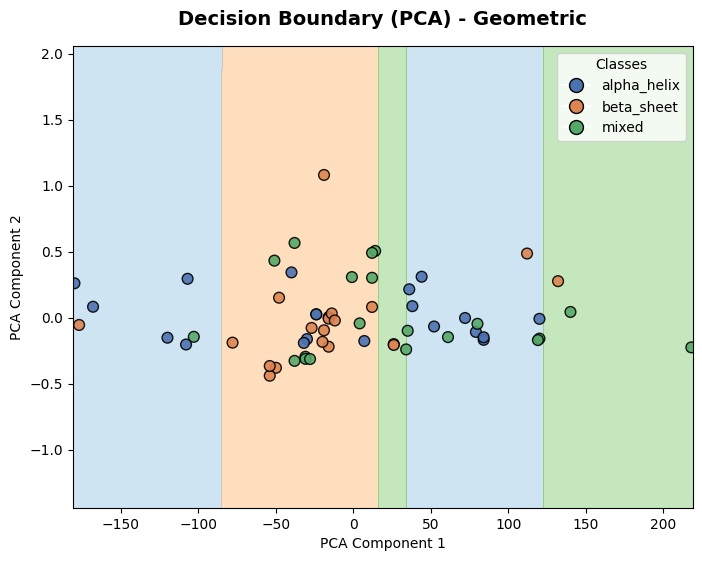

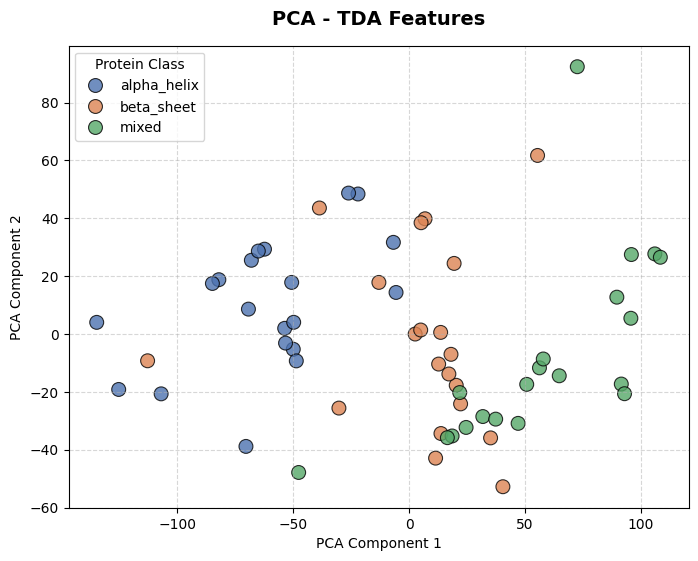

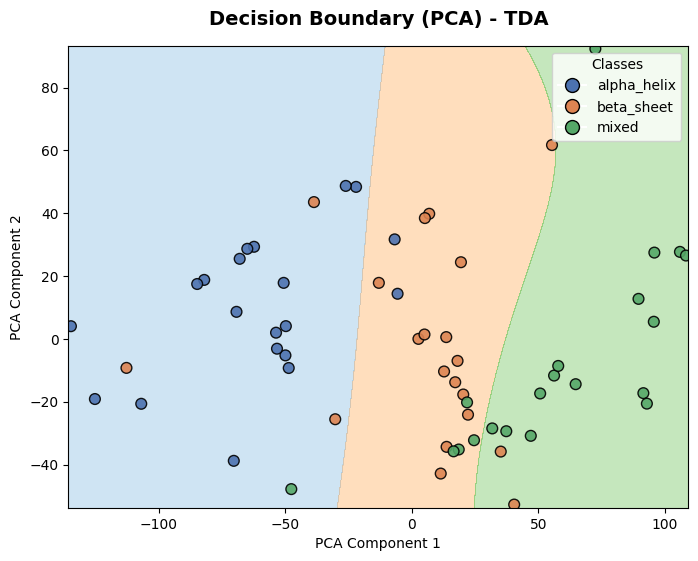

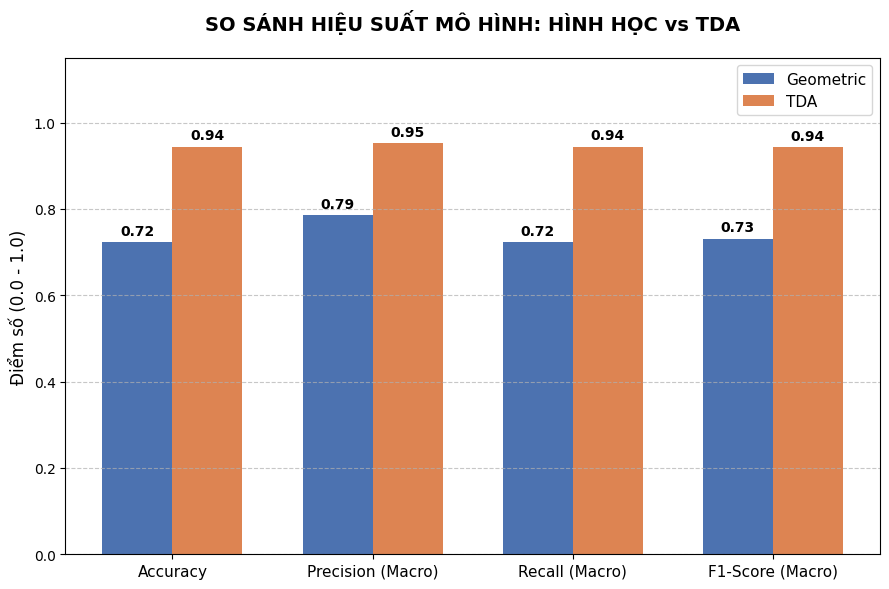

In [5]:
def load_dataset_for_model(filepath):
    data = np.load(filepath, allow_pickle=True)
    X = np.array([item["features"] for item in data])
    y = np.array([item["label"] for item in data])
    return X, y

class_names = ["alpha_helix", "beta_sheet", "mixed"]
le = LabelEncoder()
le.fit(class_names)

X_geo, y_geo_str = load_dataset_for_model(config.GEO_FEATURES_FILE)
y_geo = le.transform(y_geo_str)
svm_geo = SVMClassifier(**config.SVM_PARAMS, verbose=False)
metrics_geo = svm_geo.fit(X_geo, y_geo)

X_tda, y_tda_str = load_dataset_for_model(config.PIMAGE_FEATURES_FILE)
y_tda = le.transform(y_tda_str)
svm_tda = SVMClassifier(**config.SVM_PARAMS, verbose=False)
metrics_tda = svm_tda.fit(X_tda, y_tda)
plot_confusion_matrix(metrics_geo['confusion_matrix'], class_names, title='Confusion Matrix - Hình học')
plt.show()
plot_confusion_matrix(metrics_tda['confusion_matrix'], class_names, title='Confusion Matrix - TDA (PI)')
plt.show()

plot_feature_space(X_geo, y_geo, class_names, title="PCA - Geometric Features")
plt.show()
plot_pca_decision_boundary(X_geo, y_geo, config.PARAMS, class_names, title="Decision Boundary (PCA) - Geometric")
plt.show()

plot_feature_space(X_tda, y_tda, class_names, title="PCA - TDA Features")
plt.show()
plot_pca_decision_boundary(X_tda, y_tda, config.PARAMS, class_names, title="Decision Boundary (PCA) - TDA")
plt.show()

plot_model_comparison(metrics_geo, metrics_tda, "Geometric", "TDA")
plt.show()


 TÍNH TOÁN THỐNG KÊ KHOẢNG CÁCH WASSERSTEIN
[*] Đang trích xuất Persistence Diagram cho 15 Alpha và 15 Beta...
[*] Đang tính khoảng cách nội lớp (Alpha-Alpha và Beta-Beta)...
[*] Đang tính khoảng cách liên lớp (Alpha-Beta)...

✅ KẾT QUẢ THỐNG KÊ (Mean ± SD):
 -> CÙNG LOẠI (Nội lớp - 210 cặp): 7.0185 ± 2.7947
 -> KHÁC LOẠI (Liên lớp - 225 cặp): 9.0580 ± 2.9510


/tmp/ipykernel_10851/2405724924.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, patch_artist=True, labels=labels,


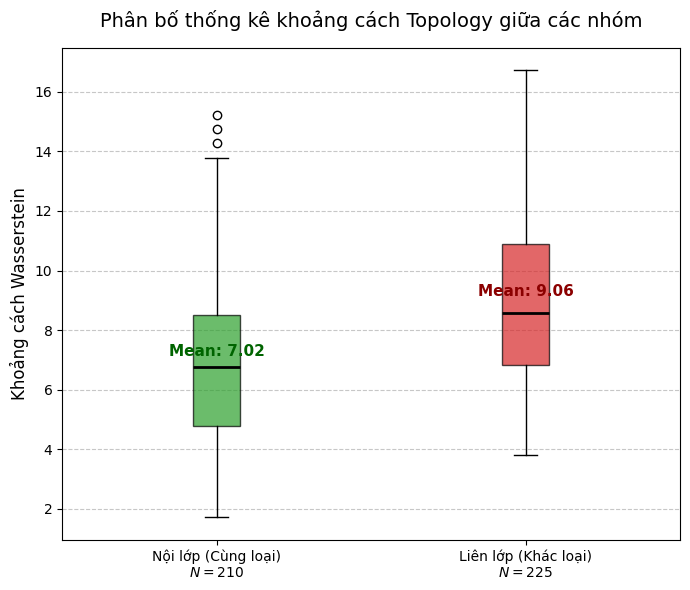

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
import gudhi as gd
from gudhi.wasserstein import wasserstein_distance
from src import config

def plot_wasserstein_distance_stats(dataset, sample_size=15, save_dir=None):
    """
    Tính toán và vẽ biểu đồ boxplot thống kê khoảng cách Wasserstein 
    giữa các biểu đồ Persistence (Nội lớp vs Liên lớp).
    """
    print(f"\n{'='*70}\n TÍNH TOÁN THỐNG KÊ KHOẢNG CÁCH WASSERSTEIN\n{'='*70}")

    def get_h1_diagram(points):
        rips = gd.RipsComplex(points=points, max_edge_length=1.5)
        st = rips.create_simplex_tree(max_dimension=2)
        persistence = st.persistence()
        
        # Chỉ lấy H1
        raw_h1 = [interval[1] for interval in persistence if interval[0] == 1]
        
        # Lọc các điểm inf (chưa chết)
        clean_h1 = [pt for pt in raw_h1 if pt[1] != float('inf')]
        return np.array(clean_h1) if len(clean_h1) > 0 else np.array([[0.0, 0.0]])

    # Lấy mẫu từ dataset
    alphas = [item for item in dataset if item["label"] == "alpha_helix"][:sample_size]
    betas = [item for item in dataset if item["label"] == "beta_sheet"][:sample_size]

    if len(alphas) < 2 or len(betas) < 2:
        print("[!] Không đủ dữ liệu Alpha/Beta trong dataset để tính Wasserstein.")
        return

    print(f"[*] Đang trích xuất Persistence Diagram cho {len(alphas)} Alpha và {len(betas)} Beta...")
    pd_alphas = [get_h1_diagram(p["point_cloud"]) for p in alphas]
    pd_betas = [get_h1_diagram(p["point_cloud"]) for p in betas]

    intra_distances = [] 
    inter_distances = [] 

    print("[*] Đang tính khoảng cách nội lớp (Alpha-Alpha và Beta-Beta)...")
    for i, j in itertools.combinations(range(len(pd_alphas)), 2):
        dist = wasserstein_distance(pd_alphas[i], pd_alphas[j], order=1, internal_p=2)
        if dist != float('inf'): intra_distances.append(dist)
        
    for i, j in itertools.combinations(range(len(pd_betas)), 2):
        dist = wasserstein_distance(pd_betas[i], pd_betas[j], order=1, internal_p=2)
        if dist != float('inf'): intra_distances.append(dist)

    print("[*] Đang tính khoảng cách liên lớp (Alpha-Beta)...")
    for i in range(len(pd_alphas)):
        for j in range(len(pd_betas)):
            dist = wasserstein_distance(pd_alphas[i], pd_betas[j], order=1, internal_p=2)
            if dist != float('inf'): inter_distances.append(dist)

    # Tránh lỗi chia cho 0 nếu mảng rỗng
    if not intra_distances or not inter_distances:
        print("[!] Không tính được khoảng cách nào.")
        return

    mean_intra = np.mean(intra_distances)
    std_intra = np.std(intra_distances)
    mean_inter = np.mean(inter_distances)
    std_inter = np.std(inter_distances)

    print(f"\n✅ KẾT QUẢ THỐNG KÊ (Mean ± SD):")
    print(f" -> CÙNG LOẠI (Nội lớp - {len(intra_distances)} cặp): {mean_intra:.4f} ± {std_intra:.4f}")
    print(f" -> KHÁC LOẠI (Liên lớp - {len(inter_distances)} cặp): {mean_inter:.4f} ± {std_inter:.4f}")

    # Vẽ Boxplot
    with plt.rc_context({'text.usetex': False, 'font.family': 'sans-serif'}):
        data_to_plot = [intra_distances, inter_distances]
        labels = [f'Nội lớp (Cùng loại)\n$N={len(intra_distances)}$', 
                  f'Liên lớp (Khác loại)\n$N={len(inter_distances)}$']
        
        plt.figure(figsize=(7, 6))
        
        box = plt.boxplot(data_to_plot, patch_artist=True, labels=labels, 
                          medianprops={'color': 'black', 'linewidth': 2})
        
        colors = ['#2ca02c', '#d62728']
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        plt.ylabel('Khoảng cách Wasserstein', fontsize=12)
        plt.title('Phân bố thống kê khoảng cách Topology giữa các nhóm', fontsize=14, pad=15)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        plt.text(1, mean_intra + 0.1, f"Mean: {mean_intra:.2f}", ha='center', fontsize=11, color='darkgreen', fontweight='bold')
        plt.text(2, mean_inter + 0.1, f"Mean: {mean_inter:.2f}", ha='center', fontsize=11, color='darkred', fontweight='bold')

        try:
            plt.tight_layout()
        except Exception:
            pass

        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, "wasserstein_distance_boxplot.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"  [+] Đã lưu biểu đồ Wasserstein tại: {save_path}")
            plt.close()
        else:
            plt.show()

# 2. LOAD DATA VÀ GỌI HÀM (Chỉ chạy ở cell này)
dataset = np.load(config.PROCESSED_DATA_FILE, allow_pickle=True)

plot_wasserstein_distance_stats(dataset, sample_size=15)